# Produção ambulatorial: procedimentos mais realizados

**Pergunta que este notebook responde:** quais procedimentos ambulatoriais o SUS
mais realizou no estado, e quanto foi pago por eles?

**Fonte:** SIA — Sistema de Informações Ambulatoriais, grupo `PA` (produção
ambulatorial).
**Tempo estimado:** 6 a 10 minutos.

> ⚠️ **Base muito grande.** Um único mês do Paraná tem **3,6 milhões de linhas
> e 253 colunas**. Como no SINAN, este notebook lê apenas as colunas
> necessárias, em vez de carregar tudo.

## Preparação

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
UF = "PR"
ANO = 2024

## Passo 1 — Achar um mês com produção ambulatorial

O SIA tem vários grupos, e o principal — `PA` — não existe em todos os estados
e meses. Vamos descobrir o que há.

In [4]:
from pysus import list_files

catalogo = list_files(dataset="sia", state=UF, year=ANO)
arquivos = sorted(nome.split("\\")[-1] for nome in catalogo["name"])

grupos = sorted({a[:2] for a in arquivos})
print(f"Grupos disponíveis em {UF}/{ANO}: {grupos}")

meses_pa = sorted({int(a[6:8]) for a in arquivos if a.startswith("PA")})
print(f"Meses com produção ambulatorial (PA): {meses_pa}")

MES = meses_pa[0] if meses_pa else None
print(f"→ Vamos usar {MES:02d}/{ANO}" if MES else "⚠ Sem PA neste recorte")

Grupos disponíveis em PR/2024: ['AB', 'AC', 'AD', 'AM', 'AQ', 'AR', 'AT', 'PA']
Meses com produção ambulatorial (PA): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
→ Vamos usar 01/2024


### O que são os outros grupos

| Grupo | Conteúdo |
|---|---|
| `PA` | Produção ambulatorial (o principal) |
| `AB` / `ABO` | APAC de cirurgia bariátrica |
| `AM` | APAC de medicamentos |
| `AN` | APAC de nefrologia |
| `AQ` | APAC de quimioterapia |
| `AR` | APAC de radioterapia |
| `AD` | APAC de laudos diversos |
| `AT` | APAC de tratamento |
| `BI` | Boletim de produção individualizada |
| `PS` | RAAS psicossocial |

APAC = Autorização de Procedimento de Alta Complexidade.

## Passo 2 — Baixar sem carregar tudo

Como no SINAN, pedimos o caminho do arquivo (`as_dataframe=False`) e depois
lemos só as colunas de interesse.

In [5]:
from pysus import sia

caminhos = sia(state=UF, year=ANO, month=MES, as_dataframe=False)
arquivo = caminhos[0]
print("Arquivo:", arquivo)

Arquivo: C:\Users\Alexandre\pysus\downloads\ducklake\sia\PAPR2401.parquet


In [6]:
import pandas as pd

COLUNAS = ["PA_PROC_ID", "PA_QTDAPR", "PA_VALAPR", "PA_MUNPCN"]

producao = pd.read_parquet(arquivo, columns=COLUNAS)

print(f"{len(producao):,} registros de produção")
print(f"Memória usada: {producao.memory_usage(deep=True).sum() / 1e9:.2f} GB "
      f"(seriam muitos GB com as 253 colunas)")

3,246,596 registros de produção


Memória usada: 0.71 GB (seriam muitos GB com as 253 colunas)


| Coluna | Significado |
|---|---|
| `PA_PROC_ID` | Código do procedimento (tabela SIGTAP) |
| `PA_QTDAPR` | Quantidade aprovada |
| `PA_VALAPR` | Valor aprovado (R$) |
| `PA_MUNPCN` | Município de residência do paciente |

## Passo 3 — Procedimentos mais realizados

In [7]:
producao["PA_QTDAPR"] = pd.to_numeric(producao["PA_QTDAPR"], errors="coerce").fillna(0)
producao["PA_VALAPR"] = pd.to_numeric(producao["PA_VALAPR"], errors="coerce").fillna(0)

por_procedimento = (
    producao.groupby("PA_PROC_ID")
    .agg(Quantidade=("PA_QTDAPR", "sum"), Valor=("PA_VALAPR", "sum"))
    .sort_values("Quantidade", ascending=False)
    .head(15)
    .reset_index()
    .rename(columns={"PA_PROC_ID": "Procedimento (SIGTAP)"})
)
por_procedimento

,Procedimento (SIGTAP),Quantidade,Valor
0,0604360037,1267825,0.0
1,0301100039,1134454,0.0
2,0201020041,811441,0.0
3,0301010064,804337,0.0
4,0604340060,638358,0.0
5,0604500050,630640,0.0
6,0301060118,618887,0.0
7,0101030010,562771,0.0
8,0301060096,513395,5647345.0
9,0604230044,479020,0.0


> Os códigos seguem a tabela **SIGTAP** do Ministério da Saúde. Os oito
> primeiros dígitos identificam o procedimento; o grupo (2 primeiros dígitos)
> indica a natureza: `02` procedimentos diagnósticos, `03` clínicos,
> `04` cirúrgicos, `01` ações de promoção e prevenção.

In [8]:
GRUPOS_SIGTAP = {
    "01": "Ações de promoção e prevenção",
    "02": "Procedimentos com finalidade diagnóstica",
    "03": "Procedimentos clínicos",
    "04": "Procedimentos cirúrgicos",
    "05": "Transplantes",
    "06": "Medicamentos",
    "07": "Órteses, próteses e materiais",
    "08": "Ações complementares",
}

producao["grupo"] = producao["PA_PROC_ID"].astype(str).str[:2].map(GRUPOS_SIGTAP)

por_grupo = (
    producao.groupby("grupo")
    .agg(Quantidade=("PA_QTDAPR", "sum"), Valor=("PA_VALAPR", "sum"))
    .sort_values("Quantidade", ascending=False)
    .reset_index()
)
por_grupo

,grupo,Quantidade,Valor
0,Medicamentos,12903201,13427065.37
1,Procedimentos clínicos,6857994,68418745.31
2,Procedimentos com finalidade diagnóstica,5631321,43972150.52
3,Ações de promoção e prevenção,1147188,16373.89
4,Ações complementares,86305,454338.90
5,Procedimentos cirúrgicos,69360,6104768.19
6,"Órteses, próteses e materiais",62183,5376446.00
7,Transplantes,9008,3050302.64


## Passo 4 — Em gráfico

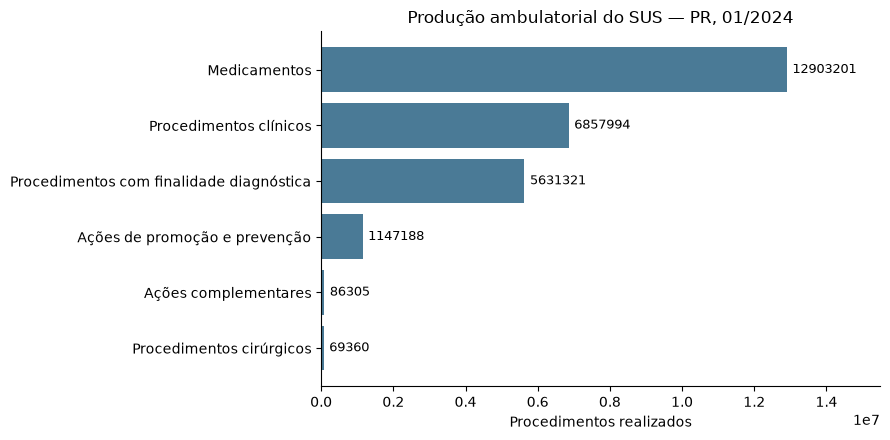

In [9]:
import matplotlib.pyplot as plt

grafico = por_grupo.dropna().head(6).sort_values("Quantidade")

fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.barh(grafico["grupo"], grafico["Quantidade"], color="#4a7a96")
ax.bar_label(barras, fmt="%.0f", padding=4, fontsize=9)

ax.set_title(f"Produção ambulatorial do SUS — {UF}, {MES:02d}/{ANO}", fontsize=12)
ax.set_xlabel("Procedimentos realizados")
ax.set_xlim(0, grafico["Quantidade"].max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Passo 5 — Total do mês

In [10]:
print(f"Estado: {UF} — {MES:02d}/{ANO}")
print(f"Procedimentos aprovados: {producao['PA_QTDAPR'].sum():>15,.0f}")
print(f"Valor total aprovado:    R$ {producao['PA_VALAPR'].sum():>15,.2f}")
print(f"Registros processados:   {len(producao):>15,}")

Estado: PR — 01/2024
Procedimentos aprovados:      26,766,560
Valor total aprovado:    R$  140,820,190.82
Registros processados:         3,246,596


## Como adaptar

- **Outro estado, ano ou mês:** mude os parâmetros — o notebook mostra quais
  meses têm produção.
- **Um procedimento específico:** filtre `PA_PROC_ID` pelo código SIGTAP.
- **Por município:** agrupe por `PA_MUNPCN` (residência do paciente), mas **tire antes o código `999999`**, que significa residência ignorada e não um município — no Paraná ele sozinho responde por 37% da produção e lideraria o ranking.
- **Por profissional:** a coluna `PA_CBOCOD` traz a ocupação de quem executou.

---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*